## EDA: Credit Approval Dataset

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
%config InlineBackend.figure_format = 'retina'

sns.set_style('darkgrid')
sns.set_palette('muted')
plt.rcParams['figure.figsize'] = (12, 8)

In [77]:
train_df = pd.read_csv('../data/needed_datasets/cs-training.csv')
test_df = pd.read_csv('../data/needed_datasets/cs-test.csv')

## Базовый осмотр

In [78]:
train_df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [79]:
test_df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


In [80]:
pd.DataFrame({
    'dataset': ['train', 'test'],
    'rows': [train_df.shape[0], test_df.shape[0]],
    'columns': [train_df.shape[1], test_df.shape[1]],
})

,dataset,rows,columns
0,train,150000,12
1,test,101503,12


In [81]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

## Колонки, таргет и признаки

`SeriousDlqin2yrs` - таргет

In [82]:
target = 'SeriousDlqin2yrs'
id_col = 'Unnamed: 0'

feature_cols = [
    col for col in train_df.columns
    if col not in [target, id_col]
]

feature_cols

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

## Пропуски

In [83]:
missing_summary = pd.DataFrame({
    'train_missing': train_df.isna().sum(),
    'train_missing_pct': train_df.isna().mean() * 100,
    'test_missing': test_df.isna().sum(),
    'test_missing_pct': test_df.isna().mean() * 100,
}).sort_values('train_missing_pct', ascending=False)

missing_summary.round(2)

,train_missing,train_missing_pct,test_missing,test_missing_pct
MonthlyIncome,29731,19.82,20103,19.81
NumberOfDependents,3924,2.62,2626,2.59
Unnamed: 0,0,0.00,0,0.00
SeriousDlqin2yrs,0,0.00,101503,100.00
RevolvingUtilizationOfUnsecuredLines,0,0.00,0,0.00
age,0,0.00,0,0.00
NumberOfTime30-59DaysPastDueNotWorse,0,0.00,0,0.00
DebtRatio,0,0.00,0,0.00
NumberOfOpenCreditLinesAndLoans,0,0.00,0,0.00
NumberOfTimes90DaysLate,0,0.00,0,0.00


In [84]:
missing_flags = train_df.assign(
    MonthlyIncome_missing=train_df['MonthlyIncome'].isna(),
    NumberOfDependents_missing=train_df['NumberOfDependents'].isna(),
)

missing_flags.groupby(target)[[
    'MonthlyIncome_missing',
    'NumberOfDependents_missing',
]].mean().round(4)

,MonthlyIncome_missing,NumberOfDependents_missing
SeriousDlqin2yrs,,
0,0.2005,0.0268
1,0.1665,0.0179


## Баланс таргета

In [85]:
target_balance = pd.DataFrame({
    'count': train_df[target].value_counts().sort_index(),
    'pct': train_df[target].value_counts(normalize=True).sort_index() * 100,
})

target_balance.round(2)

,count,pct
SeriousDlqin2yrs,,
0,139974,93.32
1,10026,6.68


## Описательная статистика

In [86]:
train_df[feature_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.995, 0.999]
).T.round(3)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,99.5%,99.9%,max
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048,249.755,0.0,0.0,0.000,0.030,0.154,0.559,1.0,1.093,1.366,1571.006,50708.0
age,150000.0,52.295,14.772,0.0,24.0,29.000,41.000,52.000,63.000,78.0,87.000,89.000,94.000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421,4.193,0.0,0.0,0.000,0.000,0.000,0.000,2.0,4.000,5.000,98.000,98.0
DebtRatio,150000.0,353.005,2037.819,0.0,0.0,0.004,0.175,0.367,0.868,2449.0,4979.040,6186.010,10613.074,329664.0
MonthlyIncome,120269.0,6670.221,14384.674,0.0,0.0,1300.000,3400.000,5400.000,8249.000,14587.6,25000.000,35000.000,78395.748,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.453,5.146,0.0,0.0,2.000,5.000,8.000,11.000,18.0,24.000,27.000,34.000,58.0
NumberOfTimes90DaysLate,150000.0,0.266,4.169,0.0,0.0,0.000,0.000,0.000,0.000,1.0,3.000,4.000,98.000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018,1.130,0.0,0.0,0.000,0.000,1.000,2.000,3.0,4.000,6.000,9.000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240,4.155,0.0,0.0,0.000,0.000,0.000,0.000,1.0,2.000,3.000,98.000,98.0
NumberOfDependents,146076.0,0.757,1.115,0.0,0.0,0.000,0.000,0.000,1.000,3.0,4.000,5.000,6.000,20.0


## Распределения признаков

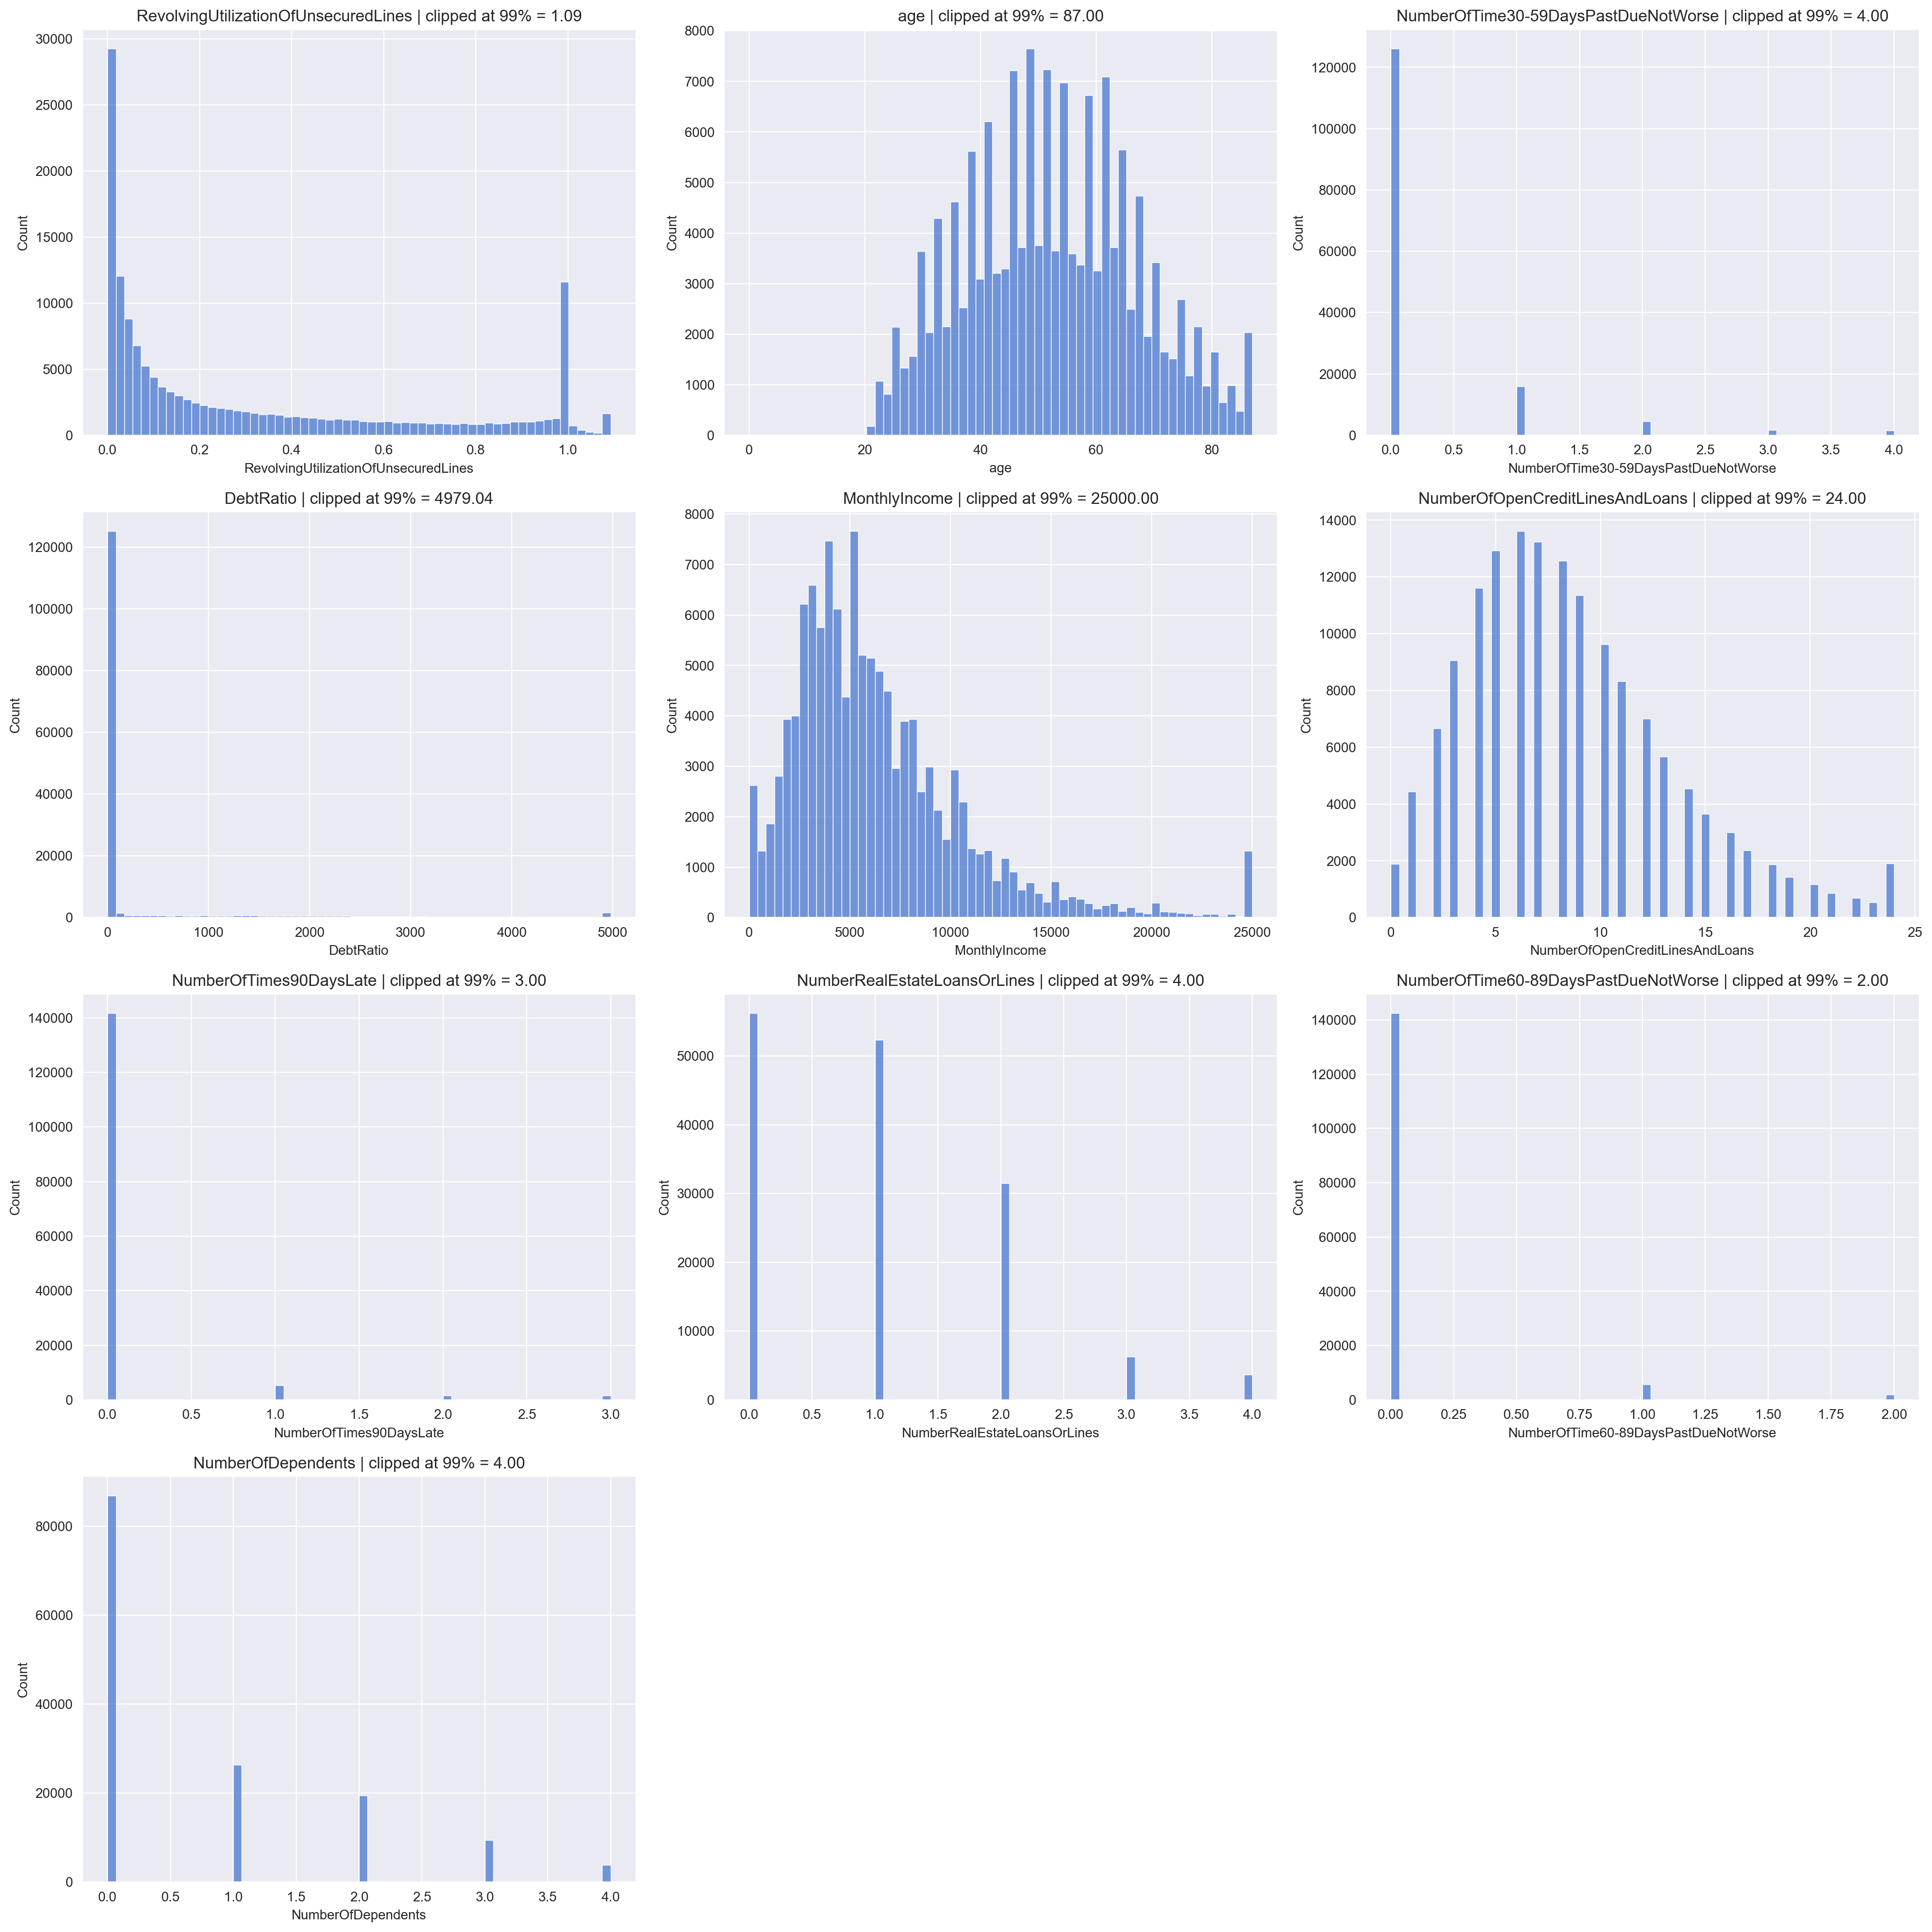

In [87]:
ncols = 3
nrows = int(np.ceil(len(feature_cols) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 5 * nrows))
axes = axes.flat

for i, feature in enumerate(feature_cols):
    upper = train_df[feature].quantile(0.99)
    sns.histplot(train_df[feature].clip(upper=upper), bins=60, ax=axes[i])
    axes[i].set_title(f'{feature} | clipped at 99% = {upper:.2f}')
    axes[i].set_xlabel(feature)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Аномалии и выбросы

In [88]:
late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
]

anomaly_summary = pd.Series({
    'age_eq_0': (train_df['age'] == 0).sum(),
    'past_due_any_ge_90': train_df[late_cols].ge(90).any(axis=1).sum(),
    'revolving_utilization_gt_1': (train_df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum(),
    'debt_ratio_gt_1': (train_df['DebtRatio'] > 1).sum(),
    'monthly_income_eq_0': (train_df['MonthlyIncome'] == 0).sum(),
    'monthly_income_missing': train_df['MonthlyIncome'].isna().sum(),
    'dependents_missing': train_df['NumberOfDependents'].isna().sum(),
})

anomaly_summary

age_eq_0                          1
past_due_any_ge_90              269
revolving_utilization_gt_1     3321
debt_ratio_gt_1               35137
monthly_income_eq_0            1634
monthly_income_missing        29731
dependents_missing             3924
dtype: int64

In [89]:
late_special_values = pd.DataFrame({
    col: train_df.loc[train_df[col] >= 90, col].value_counts().sort_index()
    for col in late_cols
}).fillna(0).astype(int)

late_special_values

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
96,5,5,5
98,264,264,264


In [90]:
train_df.loc[
    train_df[late_cols].ge(90).any(axis=1),
    late_cols + [target]
].head(20)

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,SeriousDlqin2yrs
1733,98,98,98,1
2286,98,98,98,0
3884,98,98,98,0
4417,98,98,98,0
4705,98,98,98,0
5073,98,98,98,0
6280,98,98,98,1
7032,98,98,98,1
7117,98,98,98,1
7687,98,98,98,1


In [91]:
tail_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome',
]

train_df[tail_cols].quantile([0.95, 0.99, 0.995, 0.999, 1.0]).T.round(3)

,0.950,0.990,0.995,0.999,1.000
RevolvingUtilizationOfUnsecuredLines,1.0,1.093,1.366,1571.006,50708.0
DebtRatio,2449.0,4979.040,6186.010,10613.074,329664.0
MonthlyIncome,14587.6,25000.000,35000.000,78395.748,3008750.0


## Связь признаков с таргетом

In [92]:
train_df.groupby(target)[feature_cols].median().T.round(3)

SeriousDlqin2yrs,0,1
RevolvingUtilizationOfUnsecuredLines,0.133,0.839
age,52.000,45.000
NumberOfTime30-59DaysPastDueNotWorse,0.000,0.000
DebtRatio,0.363,0.428
MonthlyIncome,5466.000,4500.000
NumberOfOpenCreditLinesAndLoans,8.000,7.000
NumberOfTimes90DaysLate,0.000,0.000
NumberRealEstateLoansOrLines,1.000,1.000
NumberOfTime60-89DaysPastDueNotWorse,0.000,0.000
NumberOfDependents,0.000,0.000


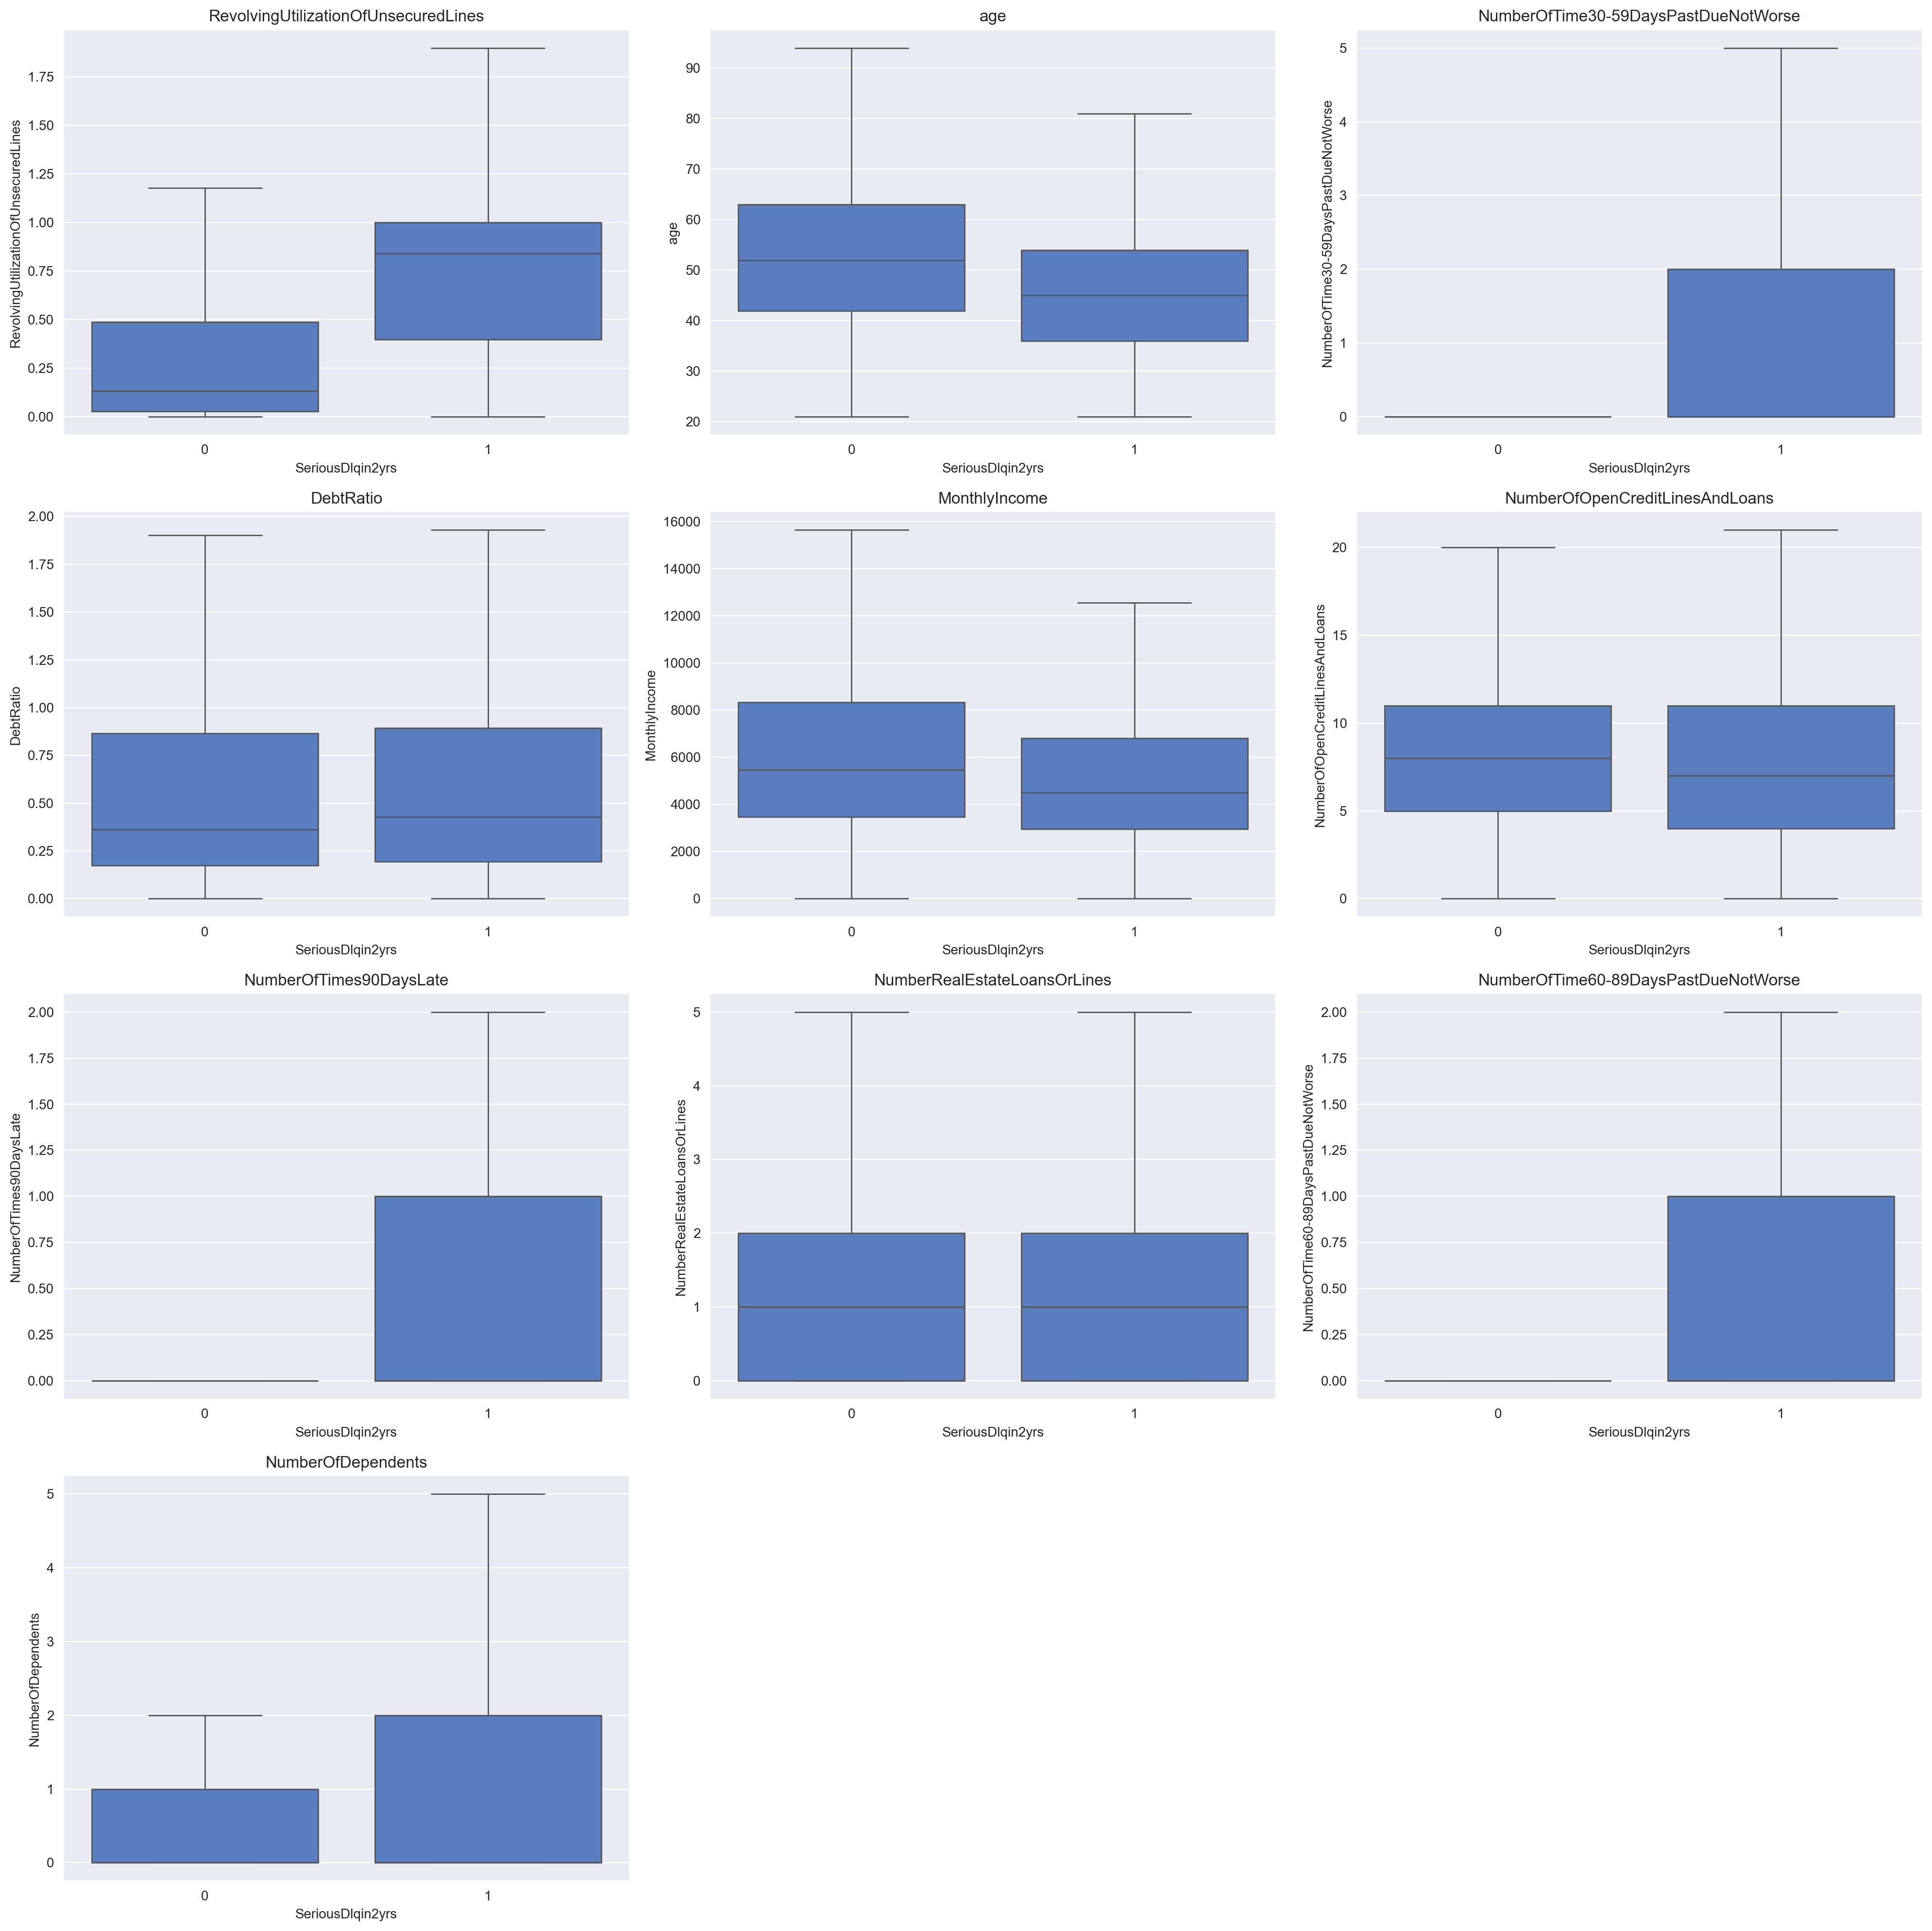

In [93]:
ncols = 3
nrows = int(np.ceil(len(feature_cols) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 5 * nrows))
axes = axes.flat

for i, feature in enumerate(feature_cols):
    sns.boxplot(
        data=train_df,
        x=target,
        y=feature,
        ax=axes[i],
        showfliers=False,
    )
    axes[i].set_title(feature)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Корреляции

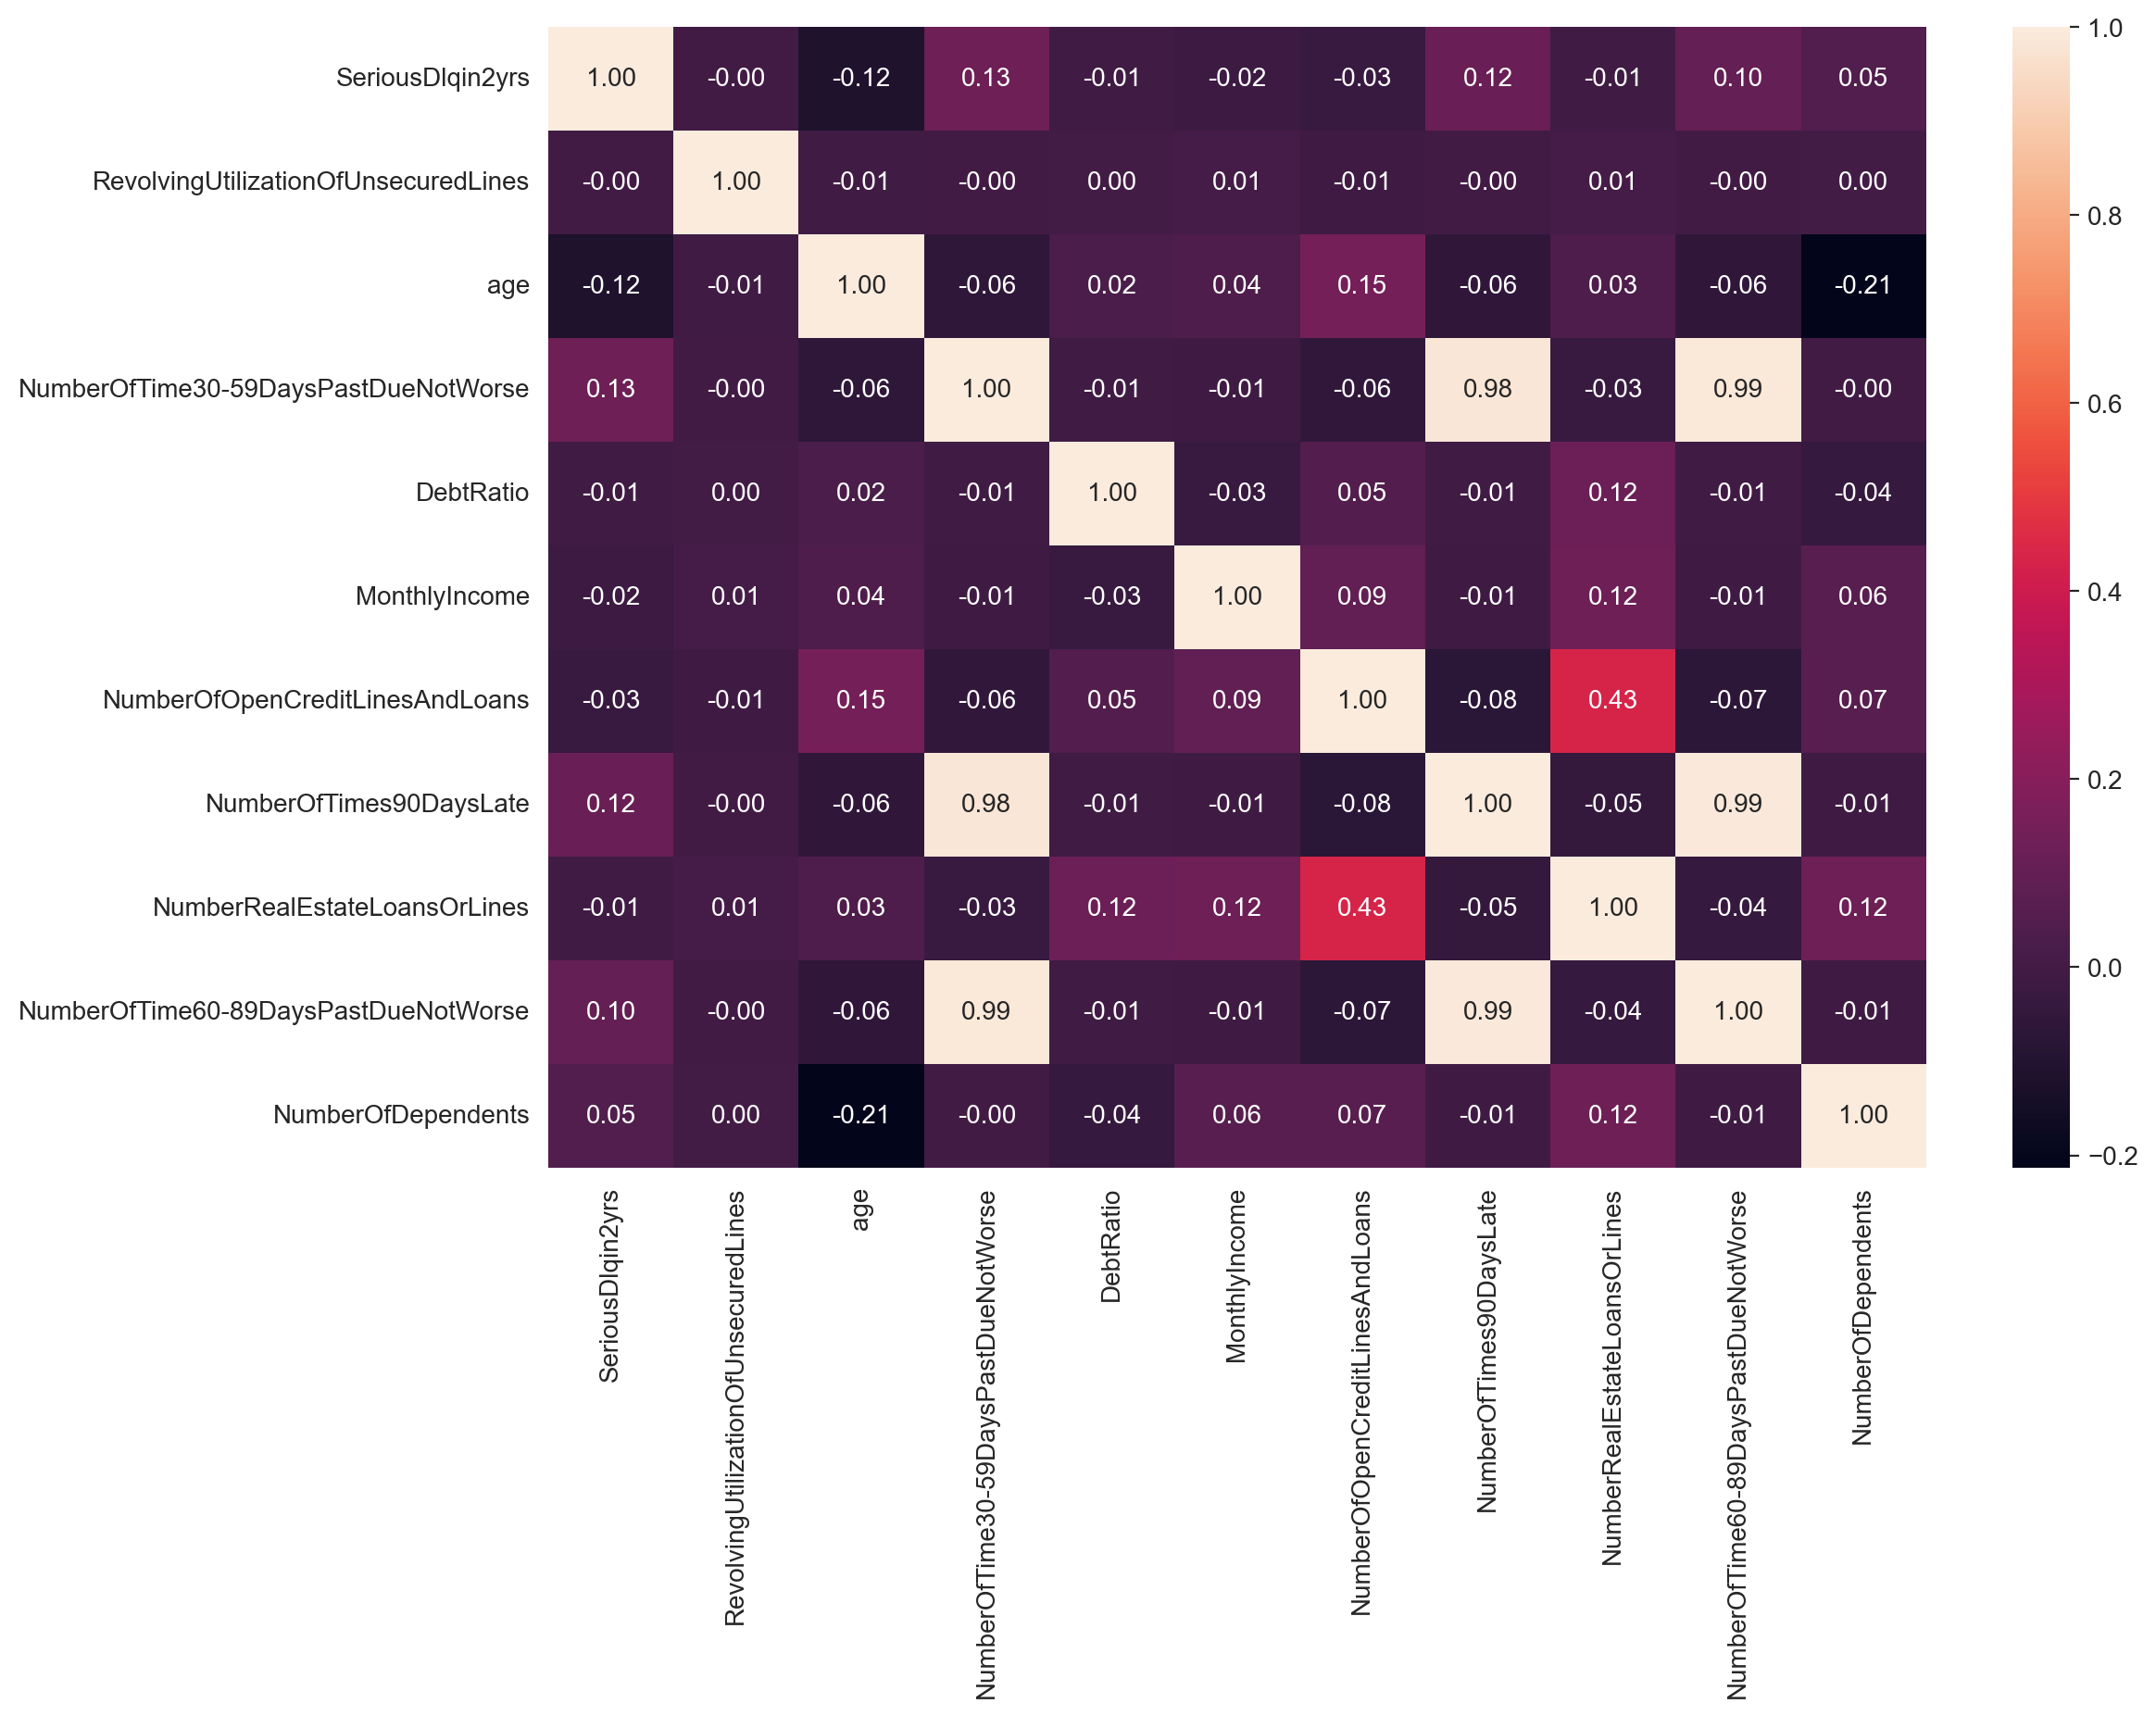

In [97]:
corr_cols = [target] + feature_cols

sns.heatmap(
    train_df[corr_cols].corr(),
    annot=True,
    fmt='.2f',
)
plt.show()

## Фича инжиниринг

In [98]:
eda_df = train_df.copy()

eda_df['total_past_due'] = (
    eda_df['NumberOfTime30-59DaysPastDueNotWorse']
    + eda_df['NumberOfTime60-89DaysPastDueNotWorse']
    + eda_df['NumberOfTimes90DaysLate']
)

eda_df['has_past_due'] = eda_df['total_past_due'] > 0
eda_df['MonthlyIncome_missing'] = eda_df['MonthlyIncome'].isna()
eda_df['NumberOfDependents_missing'] = eda_df['NumberOfDependents'].isna()

eda_df.groupby(target)[[
    'total_past_due',
    'has_past_due',
    'MonthlyIncome_missing',
    'NumberOfDependents_missing',
]].agg(['mean', 'median']).round(4)

total_past_due        has_past_due         \
                           mean median         mean median   
SeriousDlqin2yrs                                             
0                        0.5420    0.0       0.1686    0.0   
1                        6.3079    1.0       0.6744    1.0   

                 MonthlyIncome_missing        NumberOfDependents_missing  \
                                  mean median                       mean   
SeriousDlqin2yrs                                                           
0                               0.2005    0.0                     0.0268   
1                               0.1665    0.0                     0.0179   

                         
                 median  
SeriousDlqin2yrs         
0                   0.0  
1                   0.0

In [99]:
eda_df.groupby('has_past_due')[target].agg(['count', 'mean']).round(4)

,count,mean
has_past_due,,
False,119637,0.0273
True,30363,0.2227


## Предварительные выводы

- `Unnamed: 0` удалить из признаков
- Делать split из `cs-training.csv`, потому что в test нет таргета
- Использовать stratified split из-за дисбаланса таргета
- Для `MonthlyIncome` и `NumberOfDependents` проверить imputation + missing flags
- `age = 0` обработать как аномалию: например заменить на `NaN` и затем заполнить
- Значения `96/98` в трех признаках просрочек обработать как специальный код/аномалию или добавить отдельный флаг